# Cargar dataset z64


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd

path = "/content/drive/MyDrive/BCAM/distr_sol_pv_segm_embeddings_v2.npz"

data = np.load(path, allow_pickle=True)

X = data["features"].astype(np.float32)
y = data["label"].astype(int)

print("X:", X.shape)
print("y:", y.shape)

print("\nDistribución de clases:")
display(pd.Series(y).value_counts())

Mounted at /content/drive
X: (20976, 64)
y: (20976,)

Distribución de clases:


,count
1,10683
0,10293


# Train / Validation / Test Split


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("train:", X_train.shape, np.unique(y_train, return_counts=True))
print("valid:", X_valid.shape, np.unique(y_valid, return_counts=True))
print("test :", X_test.shape, np.unique(y_test, return_counts=True))

train: (14683, 64) (array([0, 1]), array([7205, 7478]))
valid: (3146, 64) (array([0, 1]), array([1544, 1602]))
test : (3147, 64) (array([0, 1]), array([1544, 1603]))


# Estandarización del espacio latente z64


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_valid_scaled:", X_valid_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (14683, 64)
X_valid_scaled: (3146, 64)
X_test_scaled : (3147, 64)


# Configuración PyTorch


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(42)

if device == "cuda":
    torch.cuda.manual_seed_all(42)

Device: cuda


# DataLoader para entrenamiento del Autoencoder


In [5]:
batch_size = 256

train_ds = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32)
)

valid_ds = TensorDataset(
    torch.tensor(X_valid_scaled, dtype=torch.float32)
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))

Train batches: 58
Valid batches: 13


# Arquitectura del Autoencoder No Lineal


In [6]:
class NonlinearAE(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )

    def forward(self, x):

        z = self.encoder(x)

        x_hat = self.decoder(z)

        return x_hat

# Función de entrenamiento del Autoencoder


In [7]:
def train_nonlinear_ae(latent_dim, epochs=100, lr=1e-3, weight_decay=1e-5, patience=15):

    model = NonlinearAE(latent_dim).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.MSELoss()

    best_valid_loss = np.inf
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "valid_loss": []
    }

    for epoch in range(1, epochs + 1):

        model.train()
        train_losses = []

        for (xb,) in train_loader:

            xb = xb.to(device)

            optimizer.zero_grad()

            x_hat = model(xb)

            loss = criterion(x_hat, xb)

            loss.backward()

            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        valid_losses = []

        with torch.no_grad():

            for (xb,) in valid_loader:

                xb = xb.to(device)

                x_hat = model(xb)

                loss = criterion(x_hat, xb)

                valid_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        valid_loss = float(np.mean(valid_losses))

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)

        if valid_loss < best_valid_loss:

            best_valid_loss = valid_loss
            best_state = model.state_dict()
            patience_counter = 0

        else:

            patience_counter += 1

        if patience_counter >= patience:

            break

    model.load_state_dict(best_state)

    return model, history

# Estudio de reconstrucción z64 → AE(k) → z64


In [8]:
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

recon_results_ae_nl = []

histories_ae_nl = {}

for k in tqdm(range(1, 65), desc="Reconstrucción AE no lineal 1-64"):

    model, history = train_nonlinear_ae(
        latent_dim=k,
        epochs=100,
        lr=1e-3,
        weight_decay=1e-5,
        patience=15
    )

    histories_ae_nl[k] = history

    model.eval()

    with torch.no_grad():

        X_train_tensor = torch.tensor(
            X_train_scaled,
            dtype=torch.float32
        ).to(device)

        X_test_tensor = torch.tensor(
            X_test_scaled,
            dtype=torch.float32
        ).to(device)

        X_train_rec = model(X_train_tensor).cpu().numpy()
        X_test_rec = model(X_test_tensor).cpu().numpy()

    recon_results_ae_nl.append({
        "AE": k,
        "MSE_train": mean_squared_error(X_train_scaled, X_train_rec),
        "MSE_test": mean_squared_error(X_test_scaled, X_test_rec),
        "epochs_used": len(history["train_loss"])
    })

df_recon_ae_nl = pd.DataFrame(recon_results_ae_nl)

display(df_recon_ae_nl)

Reconstrucción AE no lineal 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,AE,MSE_train,MSE_test,epochs_used
0,1,0.240896,0.244292,100
1,2,0.095874,0.099134,100
2,3,0.048186,0.052036,100
3,4,0.029583,0.030800,100
4,5,0.022611,0.023241,100
...,...,...,...,...
59,60,0.003556,0.003626,100
60,61,0.003144,0.003231,100
61,62,0.003612,0.003685,100
62,63,0.003233,0.003272,100


# Curva de error de reconstrucción


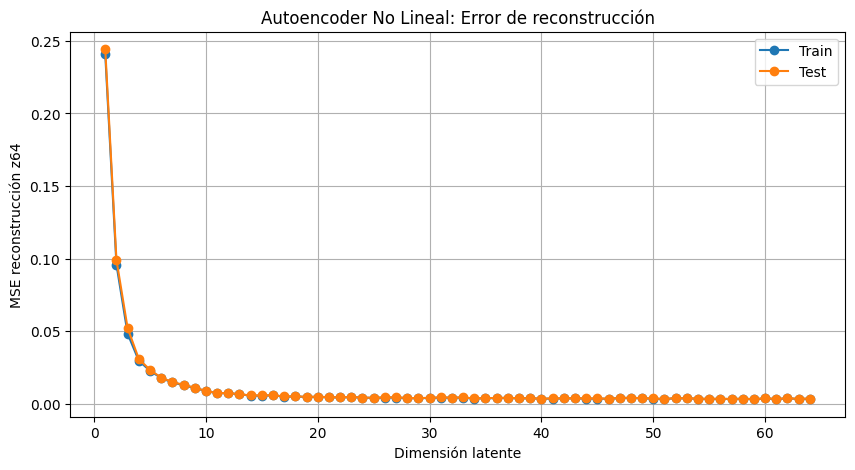

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    df_recon_ae_nl["AE"],
    df_recon_ae_nl["MSE_train"],
    marker="o",
    label="Train"
)

plt.plot(
    df_recon_ae_nl["AE"],
    df_recon_ae_nl["MSE_test"],
    marker="o",
    label="Test"
)

plt.xlabel("Dimensión latente")
plt.ylabel("MSE reconstrucción z64")
plt.title("Autoencoder No Lineal: Error de reconstrucción")
plt.grid(True)
plt.legend()
plt.show()

# Extracción de embeddings latentes


In [10]:
def extract_embedding(model, X_scaled):

    model.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X_scaled,
            dtype=torch.float32
        ).to(device)

        Z = model.encoder(X_tensor)

    return Z.cpu().numpy()

# Clasificación SVM-RBF usando embeddings del Autoencoder


In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score

results_svm_ae_nl = []

for k in tqdm(range(1, 65), desc="SVM RBF AE no lineal 1-64"):

    model, history = train_nonlinear_ae(
        latent_dim=k,
        epochs=100,
        lr=1e-3,
        weight_decay=1e-5,
        patience=15
    )

    Z_train = extract_embedding(model, X_train_scaled)
    Z_test = extract_embedding(model, X_test_scaled)

    clf = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=False,
        cache_size=1000
    )

    clf.fit(Z_train, y_train)

    y_pred = clf.predict(Z_test)
    y_score = clf.decision_function(Z_test)

    results_svm_ae_nl.append({
        "Model": "SVM_RBF",
        "AE": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_score)
    })

df_svm_ae_nl = pd.DataFrame(results_svm_ae_nl)

display(df_svm_ae_nl)

print("Mejor SVM por AUC:")
display(df_svm_ae_nl.loc[[df_svm_ae_nl["AUC"].idxmax()]])

SVM RBF AE no lineal 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,AE,Acc,F1,bAcc,AUC
0,SVM_RBF,1,0.792819,0.776712,0.794450,0.857626
1,SVM_RBF,2,0.876072,0.864017,0.878043,0.915655
2,SVM_RBF,3,0.876072,0.864771,0.877948,0.926778
3,SVM_RBF,4,0.882745,0.873326,0.884450,0.937785
4,SVM_RBF,5,0.886241,0.877145,0.887941,0.937249
...,...,...,...,...,...,...
59,SVM_RBF,60,0.894820,0.887530,0.896351,0.934609
60,SVM_RBF,61,0.891007,0.883055,0.892596,0.935324
61,SVM_RBF,62,0.892914,0.885257,0.894479,0.934740
62,SVM_RBF,63,0.892596,0.884956,0.894156,0.934712


Mejor SVM por AUC:


,Model,AE,Acc,F1,bAcc,AUC
3,SVM_RBF,4,0.882745,0.873326,0.88445,0.937785


# Clasificación Random Forest usando embeddings del Autoencoder


In [12]:
from sklearn.ensemble import RandomForestClassifier

results_rf_ae_nl = []

for k in tqdm(range(1, 65), desc="Random Forest AE no lineal 1-64"):

    model, history = train_nonlinear_ae(
        latent_dim=k,
        epochs=100,
        lr=1e-3,
        weight_decay=1e-5,
        patience=15
    )

    Z_train = extract_embedding(model, X_train_scaled)
    Z_test = extract_embedding(model, X_test_scaled)

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(Z_train, y_train)

    y_pred = clf.predict(Z_test)
    y_prob = clf.predict_proba(Z_test)[:, 1]

    results_rf_ae_nl.append({
        "Model": "Random_Forest",
        "AE": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

df_rf_ae_nl = pd.DataFrame(results_rf_ae_nl)

display(df_rf_ae_nl)

print("Mejor Random Forest por AUC:")
display(df_rf_ae_nl.loc[[df_rf_ae_nl["AUC"].idxmax()]])

Random Forest AE no lineal 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,AE,Acc,F1,bAcc,AUC
0,Random_Forest,1,0.742930,0.750540,0.742619,0.847365
1,Random_Forest,2,0.843343,0.838414,0.844212,0.914024
2,Random_Forest,3,0.873848,0.867975,0.874990,0.926847
3,Random_Forest,4,0.881792,0.876658,0.882883,0.939496
4,Random_Forest,5,0.883699,0.878888,0.884754,0.940182
...,...,...,...,...,...,...
59,Random_Forest,60,0.891643,0.886295,0.892838,0.946894
60,Random_Forest,61,0.895456,0.890370,0.896641,0.947572
61,Random_Forest,62,0.893867,0.888667,0.895058,0.945754
62,Random_Forest,63,0.891961,0.886667,0.893150,0.946511


Mejor Random Forest por AUC:


,Model,AE,Acc,F1,bAcc,AUC
30,Random_Forest,31,0.893232,0.88785,0.894446,0.948889


# Clasificación Logistic Regression usando embeddings del Autoencoder


In [13]:
from sklearn.linear_model import LogisticRegression

results_lr_ae_nl = []

for k in tqdm(range(1, 65), desc="Logistic Regression AE no lineal 1-64"):

    model, history = train_nonlinear_ae(
        latent_dim=k,
        epochs=100,
        lr=1e-3,
        weight_decay=1e-5,
        patience=15
    )

    Z_train = extract_embedding(model, X_train_scaled)
    Z_test = extract_embedding(model, X_test_scaled)

    clf = LogisticRegression(
        max_iter=5000,
        random_state=42
    )

    clf.fit(Z_train, y_train)

    y_pred = clf.predict(Z_test)
    y_prob = clf.predict_proba(Z_test)[:, 1]

    results_lr_ae_nl.append({
        "Model": "Logistic_Regression",
        "AE": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

df_lr_ae_nl = pd.DataFrame(results_lr_ae_nl)

display(df_lr_ae_nl)

print("Mejor Logistic Regression por AUC:")
display(df_lr_ae_nl.loc[[df_lr_ae_nl["AUC"].idxmax()]])

Logistic Regression AE no lineal 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,AE,Acc,F1,bAcc,AUC
0,Logistic_Regression,1,0.798221,0.775539,0.800396,0.872970
1,Logistic_Regression,2,0.849698,0.839607,0.851177,0.898335
2,Logistic_Regression,3,0.880839,0.873524,0.882233,0.913829
3,Logistic_Regression,4,0.884652,0.878879,0.885857,0.937333
4,Logistic_Regression,5,0.890372,0.883799,0.891746,0.942737
...,...,...,...,...,...,...
59,Logistic_Regression,60,0.893232,0.887625,0.894481,0.946297
60,Logistic_Regression,61,0.896092,0.890891,0.897301,0.946920
61,Logistic_Regression,62,0.891325,0.885924,0.892526,0.946011
62,Logistic_Regression,63,0.895138,0.889706,0.896377,0.946956


Mejor Logistic Regression por AUC:


,Model,AE,Acc,F1,bAcc,AUC
56,Logistic_Regression,57,0.896409,0.891478,0.897577,0.948585


# Consolidación de resultados


In [14]:
df_all_ae_nl = pd.concat(
    [
        df_svm_ae_nl,
        df_rf_ae_nl,
        df_lr_ae_nl
    ],
    ignore_index=True
)

display(df_all_ae_nl)

print("Mejor resultado por modelo:")
display(
    df_all_ae_nl.loc[df_all_ae_nl.groupby("Model")["AUC"].idxmax()]
    .sort_values("AUC", ascending=False)
)

,Model,AE,Acc,F1,bAcc,AUC
0,SVM_RBF,1,0.792819,0.776712,0.794450,0.857626
1,SVM_RBF,2,0.876072,0.864017,0.878043,0.915655
2,SVM_RBF,3,0.876072,0.864771,0.877948,0.926778
3,SVM_RBF,4,0.882745,0.873326,0.884450,0.937785
4,SVM_RBF,5,0.886241,0.877145,0.887941,0.937249
...,...,...,...,...,...,...
187,Logistic_Regression,60,0.893232,0.887625,0.894481,0.946297
188,Logistic_Regression,61,0.896092,0.890891,0.897301,0.946920
189,Logistic_Regression,62,0.891325,0.885924,0.892526,0.946011
190,Logistic_Regression,63,0.895138,0.889706,0.896377,0.946956


Mejor resultado por modelo:


,Model,AE,Acc,F1,bAcc,AUC
94,Random_Forest,31,0.893232,0.887850,0.894446,0.948889
184,Logistic_Regression,57,0.896409,0.891478,0.897577,0.948585
3,SVM_RBF,4,0.882745,0.873326,0.884450,0.937785


# Comparación de AUC según dimensión latente


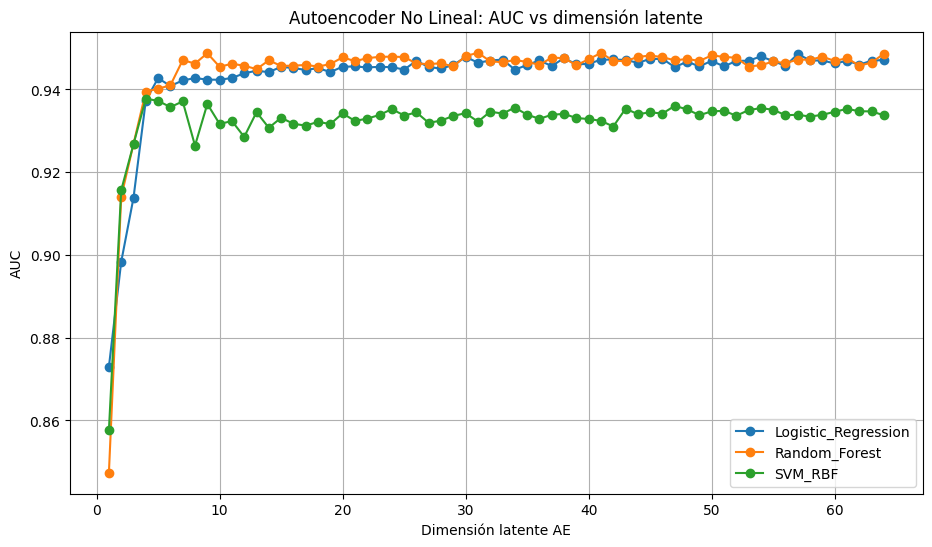

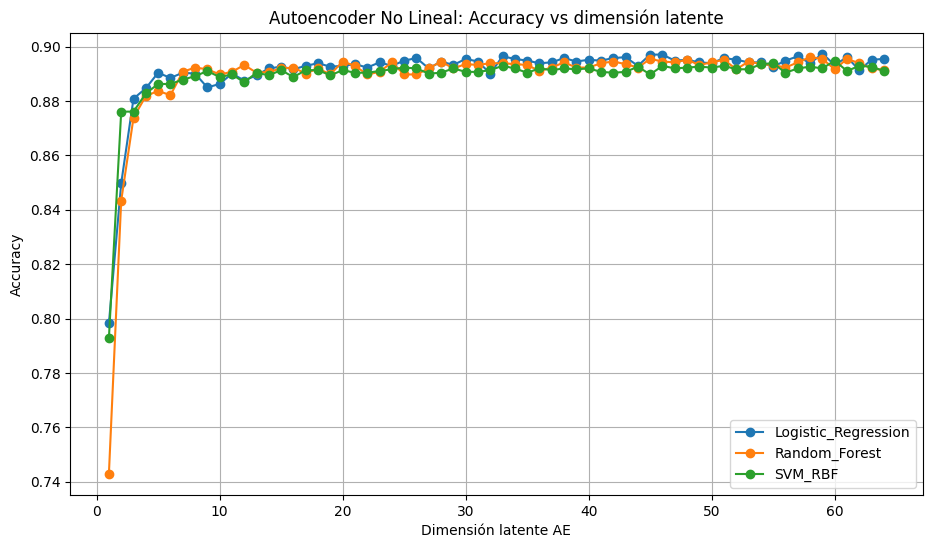

In [15]:
plt.figure(figsize=(11, 6))

for model_name, df_m in df_all_ae_nl.groupby("Model"):

    plt.plot(
        df_m["AE"],
        df_m["AUC"],
        marker="o",
        label=model_name
    )

plt.xlabel("Dimensión latente AE")
plt.ylabel("AUC")
plt.title("Autoencoder No Lineal: AUC vs dimensión latente")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(11, 6))

for model_name, df_m in df_all_ae_nl.groupby("Model"):

    plt.plot(
        df_m["AE"],
        df_m["Acc"],
        marker="o",
        label=model_name
    )

plt.xlabel("Dimensión latente AE")
plt.ylabel("Accuracy")
plt.title("Autoencoder No Lineal: Accuracy vs dimensión latente")
plt.grid(True)
plt.legend()
plt.show()